In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

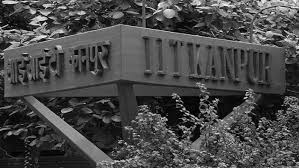

In [ ]:
img = cv2.imread("/content/iitk_0bcd2f00-d737-4e46-9e60-01ffffe1ea81.png")
cv2_imshow(img)


(168, 299, 3)


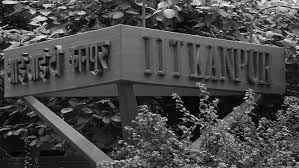

In [ ]:
print(img.shape)
img_gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_gray.shape
cv2_imshow(img_gray)

In [ ]:
def display_results(original_image, response_map, filter_name):
    """
    Normalizes and displays the original image and the filter response map.
    """
    plt.figure(figsize=(10, 5))

    # 1. Display original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    # 2. Display "Grayish Background" response (Min-Max Normalization)
    plt.subplot(1, 2, 2)
    # Check if there's any variation to avoid division by zero
    if response_map.min() != response_map.max():
        # This maps min->black, max->white, zero->mid-gray
        normalized_map = 255 * (response_map - response_map.min()) / (response_map.max() - response_map.min())
    else:
        normalized_map = np.zeros(response_map.shape)

    plt.imshow(normalized_map, cmap='gray')
    plt.title(f'Response for {filter_name}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


--- Visualization for Filter 1 ---
 (White=1, Gray=-1)
[[-1 -1  1  1]
 [-1 -1  1  1]
 [ 1  1 -1 -1]
 [ 1  1 -1 -1]]
-------------------------------------
--- Visualization for Filter 2 ---
 (White=1, Gray=-1)
[[-1 -1 -1 -1]
 [-1 -1 -1 -1]
 [ 1  1  1  1]
 [ 1  1  1  1]]
-------------------------------------
--- Visualization for Filter 3 ---
 (White=1, Gray=-1)
[[-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]]
-------------------------------------
--- Visualization for Filter 4 ---
 (White=1, Gray=-1)
[[ 1  1 -1 -1]
 [ 1  1 -1 -1]
 [-1 -1  1  1]
 [-1 -1  1  1]]
-------------------------------------
--- Visualization for Filter 5 ---
 (White=1, Gray=-1)
[[-1 -1 -1 -1]
 [-1 -1 -1 -1]
 [-1 -1  1  1]
 [-1 -1  1  1]]
-------------------------------------
--- Visualization for Filter 6 ---
 (White=1, Gray=-1)
[[ 1  1  1  1]
 [ 1 -1 -1 -1]
 [ 1 -1 -1 -1]
 [ 1 -1 -1 -1]]
-------------------------------------


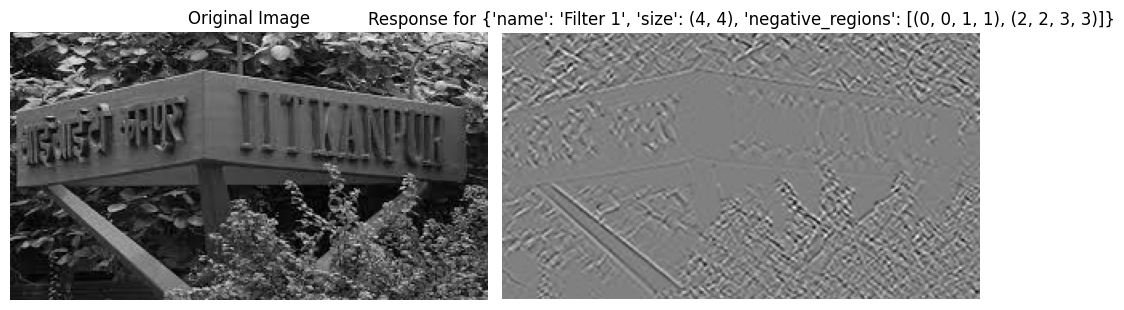

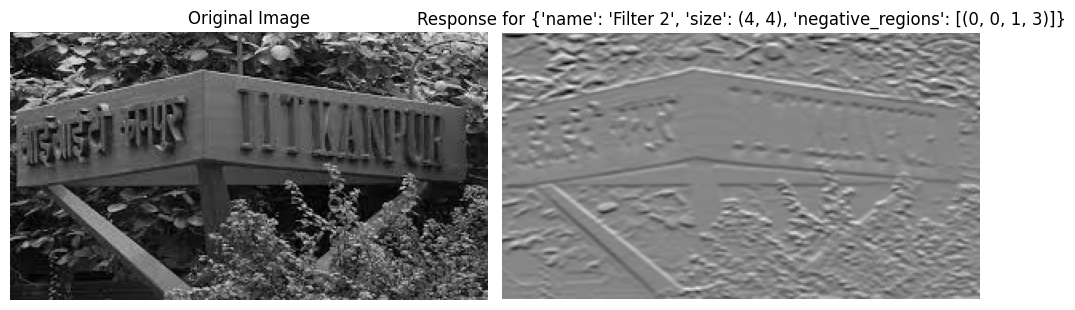

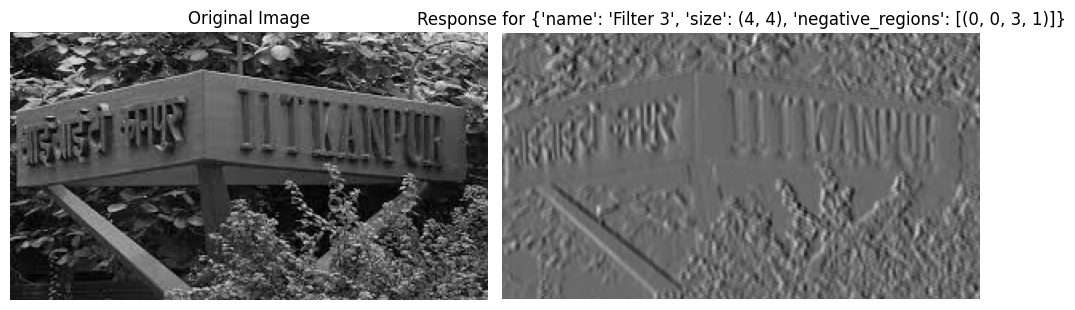

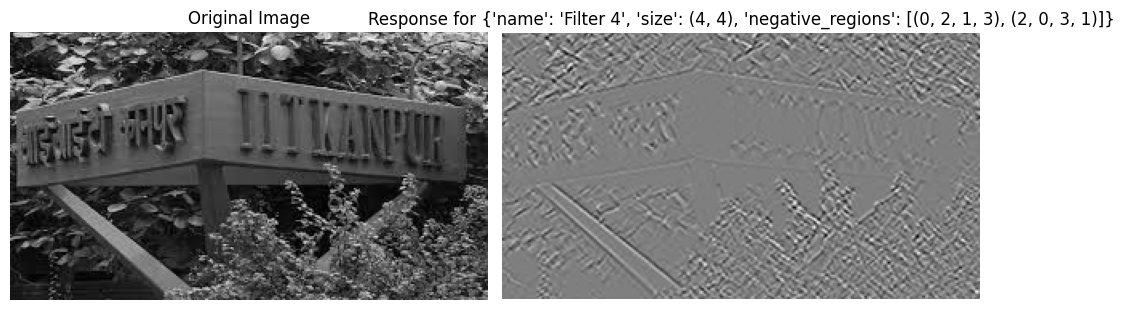

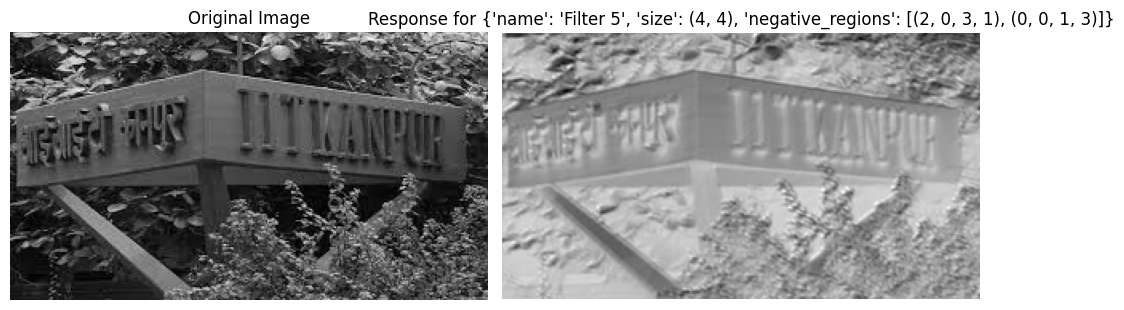

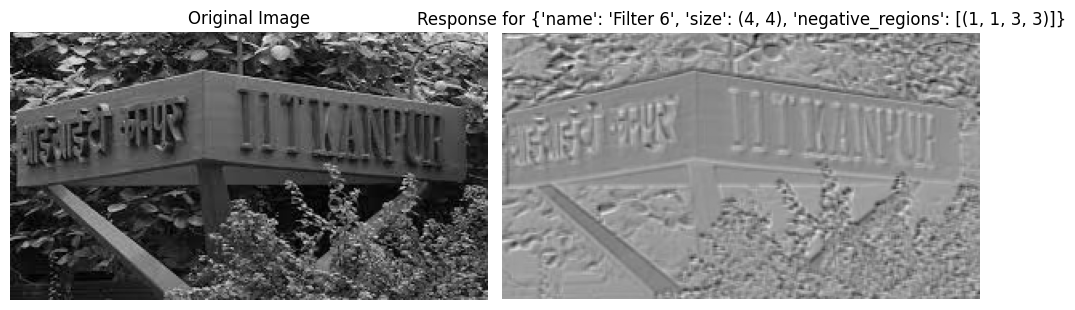

In [ ]:

def compute_integral_image(image):

    rows, cols = image.shape
    integral_image = np.zeros((rows + 1, cols + 1), dtype=int)
    for r in range(rows):
        for c in range(cols):
            integral_image[r+1, c+1] = (
                image[r, c] +
                integral_image[r, c+1] +
                integral_image[r+1, c] -
                integral_image[r, c]
            )

    return integral_image

def sum_region(integral_image, top_left, bottom_right):

    r1, c1 = top_left
    r2, c2 = bottom_right


    A = integral_image[r1, c1]
    B = integral_image[r1, c2 + 1]
    C = integral_image[r2 + 1, c1]
    D = integral_image[r2 + 1, c2 + 1]

    return D - B - C + A

def apply_filter(image, filter_def):

    integral_image = compute_integral_image(image)

    img_rows, img_cols = image.shape
    filter_rows, filter_cols = filter_def['size']


    response_map = np.zeros(
        (img_rows - filter_rows + 1, img_cols - filter_cols + 1),
        dtype=int
    )

    for r in range(response_map.shape[0]):
        for c in range(response_map.shape[1]):

            total_area_sum = sum_region(
                integral_image,
                top_left=(r, c),
                bottom_right=(r + filter_rows - 1, c + filter_cols - 1)
            )

            negative_sum = 0
            for region in filter_def['negative_regions']:

                r1_rel, c1_rel, r2_rel, c2_rel = region

                region_top_left = (r + r1_rel, c + c1_rel)
                region_bottom_right = (r + r2_rel, c + c2_rel)


                negative_sum += sum_region(integral_image, region_top_left, region_bottom_right)


            response_map[r, c] = total_area_sum - 2 * negative_sum

    return response_map

def visualize_filter(filter_def):

    filter_rows, filter_cols = filter_def['size']
    vis_array = np.ones((filter_rows, filter_cols), dtype=int)
    for r1, c1, r2, c2 in filter_def['negative_regions']:
        vis_array[r1:r2+1, c1:c2+1] = -1

    print(f"--- Visualization for {filter_def['name']} ---")
    print(" (White=1, Gray=-1)")
    print(vis_array)
    print("-" * (29 + len(filter_def['name'])))


if __name__ == '__main__':
    filters = [
        {'name': 'Filter 1', 'size': (4, 4), 'negative_regions': [(0, 0, 2, 2),(2,2,2,2)]},
        {'name': 'Filter 2', 'size': (4, 4), 'negative_regions': [(0, 0, 1, 3)]},
        {'name': 'Filter 3', 'size': (4, 4), 'negative_regions': [(0, 0,3,1)]},
        {'name': 'Filter 4', 'size': (4, 4), 'negative_regions': [(0, 2, 1, 3), (2, 0, 3, 1)]},
        {'name': 'Filter 5', 'size': (4, 4), 'negative_regions': [(2, 0, 3, 1),(0, 0, 1, 3)]},
        {'name': 'Filter 6', 'size': (4, 4), 'negative_regions': [(1,1,3,3)]},
    ]
for f in filters:

    visualize_filter(f)
    for f in filters:
        response = apply_filter(img_gray, f)
        cv2.imwrite(f"{f['name']} Output.png",response)
        display_results(img,response,f)

